In [1]:
!pip install ipywidgets scikit-network --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [3]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


/tmp/ipykernel_26504/4168379563.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)
/tmp/ipykernel_26504/4168379563.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")


We found out that dropping the rows and columns using our smart_drop_na was actually dropping too much, loosing most of the important international games(as these are missing some columns for no reason). Because of that, the graph was much less connected and now we used a different approach to drop.

In [4]:
c2_df = data.drop(data[data["position"] == "team"].index) 

In [5]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
# but there are a few players with missing playerids, we still need to remove these players for our graph mining as we use the playerids to describe the players
missing_playerids = c2_df[c2_df["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
games_with_missing_playerids = c2_df[c2_df["gameid"].isin(missing_playerids["gameid"].unique())] 
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
c2_df = c2_df.drop(games_with_missing_playerids.index)

there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


<!---
Here we explore some simple deterministic stats on top of the data that we used to better understand how we should aggregate different stats
--->

In [6]:
# For each playerid, print the number of different leagues they played in:
print(c2_df.groupby("playerid")["league"].nunique().value_counts())

league
1    1536
2     653
3     257
4      92
5      27
6       2
Name: count, dtype: int64


In [7]:
uniq_player_ids = c2_df["playerid"].unique()

print("Number of unique player ids:", len(uniq_player_ids))
# Check if uniq_player_ids contains nan
if np.nan in uniq_player_ids:
    print("Warning: uniq_player_ids contains NaN values")
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_index_to_playerid = dict(zip(range(len(uniq_player_ids)), uniq_player_ids))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

Number of unique player ids: 2567


In [8]:
for i in tqdm(range(0, len(c2_df), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(c2_df.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

  0%|          | 0/9691 [00:00<?, ?it/s]

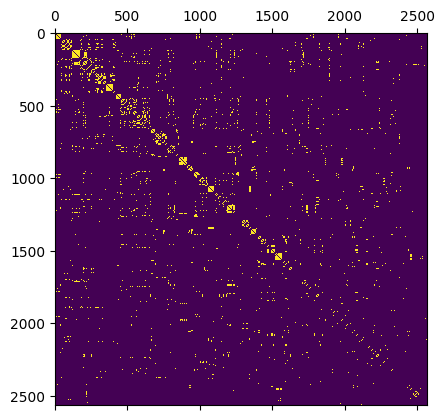

In [9]:
plt.matshow(adj_matrix)

  0%|          | 0/12 [00:00<?, ?it/s]

/home/vlad/venv/lib/python3.14/site-packages/sklearn/cluster/_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


,method,n_clusters,nmi_leagues,nmi_regions,nmi_continents,ari_leagues,ari_regions,ari_continents
5,Spectral Embedding + Gaussian Mixture (n_clust...,45,0.906105,0.566332,0.506083,0.803400,0.096172,0.091736
1,Spectral Clustering (n_clusters = 45),45,0.903293,0.563273,0.514985,0.801855,0.101205,0.102548
2,Spectral Embedding + Kmeans (n_clusters = 45),45,0.902534,0.560507,0.499328,0.796571,0.094867,0.090345
9,Adjacency Based Similarity (Multi-Hop 2) + Kme...,45,0.898178,0.553161,0.495539,0.772721,0.087766,0.084094
6,Random walk + Kmeans (n_clusters = 45),45,0.892222,0.559056,0.501295,0.782341,0.092773,0.089269
8,Adjacency Based Similarity (Adjacency) + Kmean...,45,0.890967,0.546680,0.493221,0.746138,0.082654,0.080020
7,Random walk No Jump+ Kmeans (n_clusters = 45),45,0.884802,0.546571,0.496257,0.751931,0.088257,0.088398
0,Louvain,15,0.789378,0.559922,0.528485,0.459861,0.179038,0.185329
3,"Spectral Embedding + DBSCAN (eps = 0.003, min_...",1746,0.655750,0.336493,0.299013,0.032965,0.001905,0.001829
10,Adjacency Based Similarity (Laplacian) + Kmean...,45,0.539954,0.298734,0.303099,0.233802,0.031606,0.041486


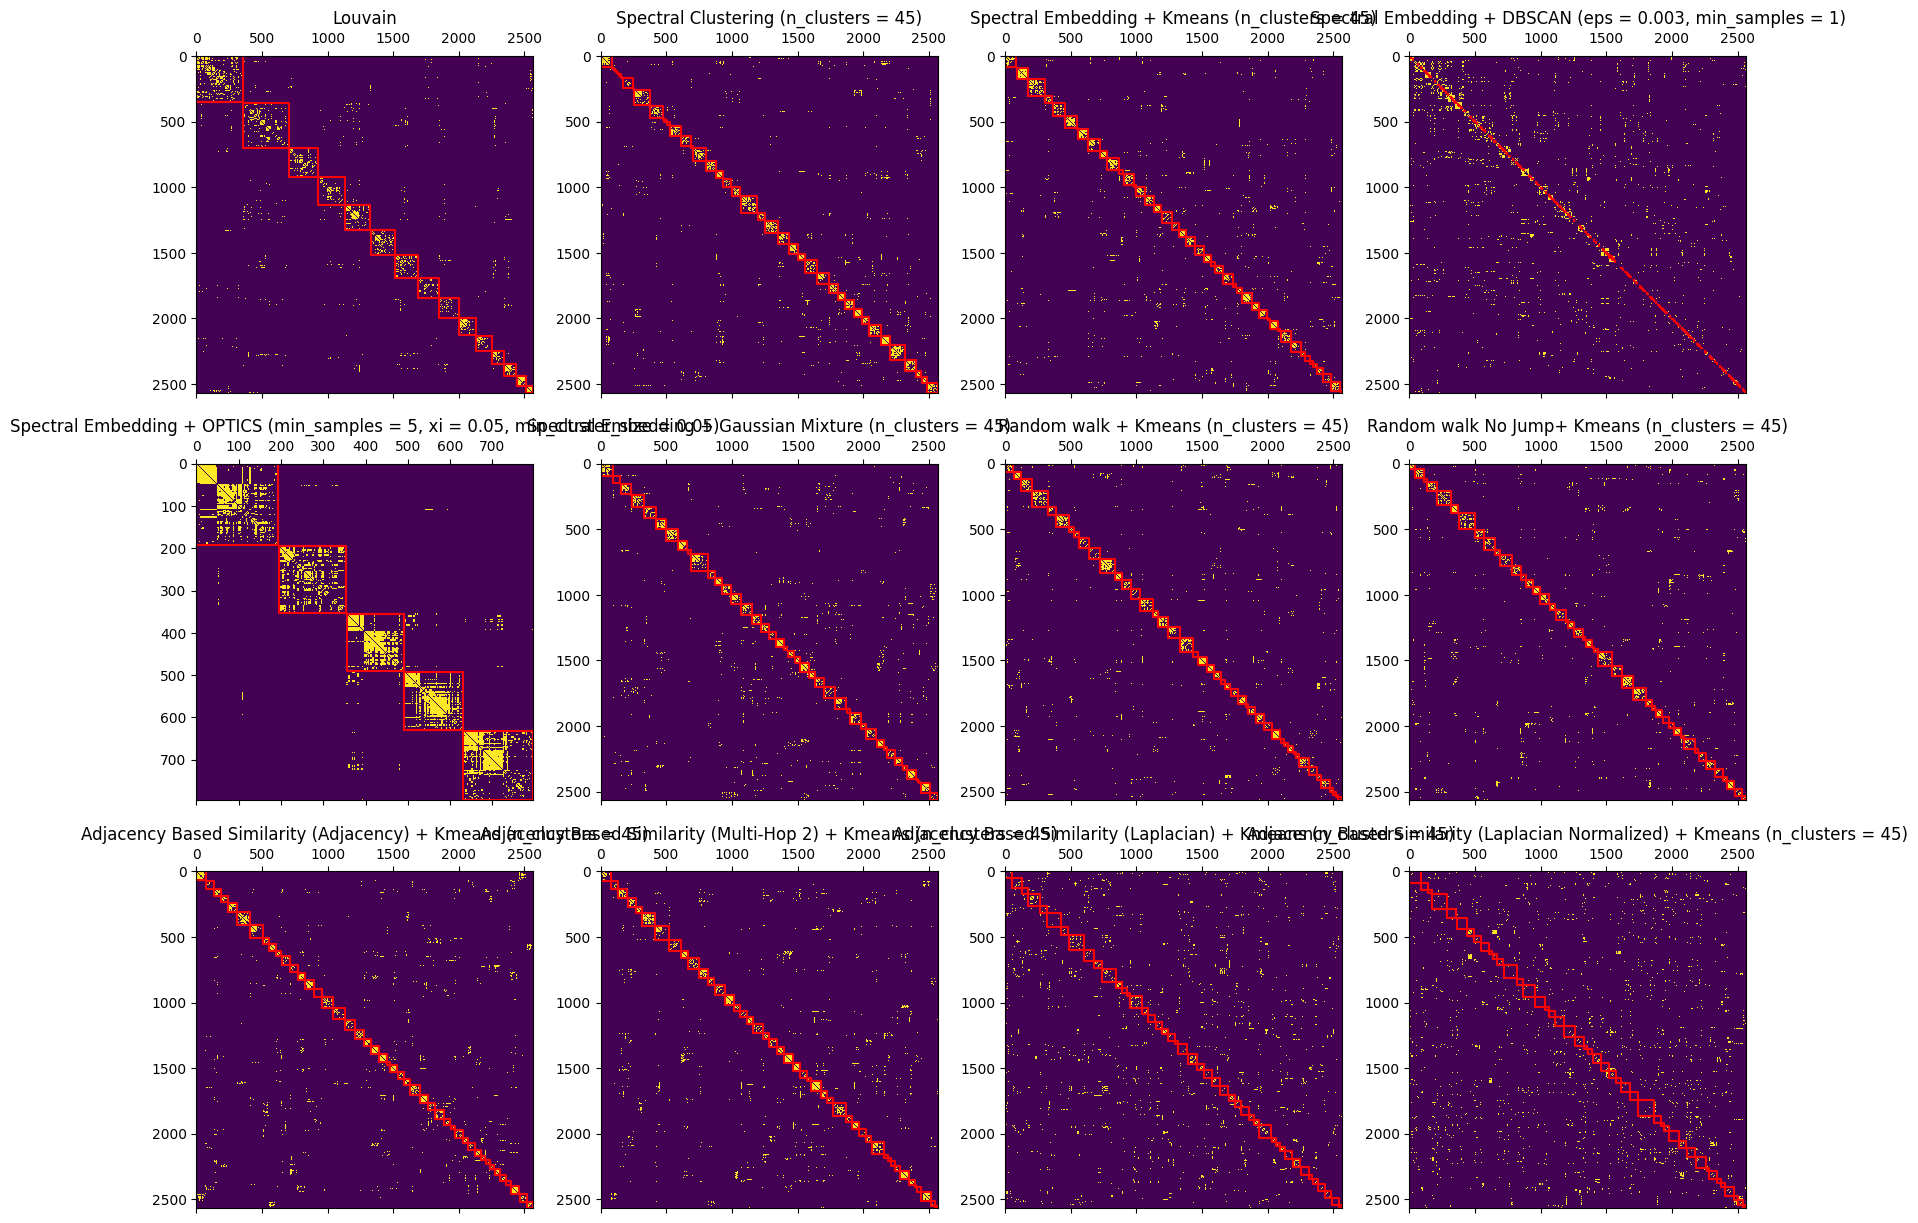

In [10]:
from sknetwork.clustering import Louvain
from sklearn.manifold import SpectralEmbedding, spectral_embedding
from sklearn.cluster import KMeans, DBSCAN, OPTICS, spectral_clustering
from sklearn.mixture import GaussianMixture

from utils.score import compute_all_metrics, score_leagues
from utils.visualize import plot_adj_matrix_sorted_by_clustering

n_clusters = 45
k_means_n_init = 100

embeddings_dir = cwd / "embeddings"

clustering_methods = [
    {
        "type": "direct",
        "name": "Louvain",
        "clustering_algorithm": lambda adj: Louvain().fit_predict(adj)
    },
    {
        "type": "direct",
        "name": "Spectral Clustering (n_clusters = {n_clusters})",
        "clustering_algorithm": lambda adj: spectral_clustering(adj, n_clusters=n_clusters, n_init=k_means_n_init)
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + DBSCAN (eps = 0.003, min_samples = 1)",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: DBSCAN(eps=0.003, min_samples=1).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + OPTICS (min_samples = 5, xi = 0.05, min_cluster_size = 0.05)",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Spectral Embedding + Gaussian Mixture (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: spectral_embedding(adj, n_components=n_clusters, random_state=1, drop_first=False),
        "clustering_algorithm": lambda embs: GaussianMixture(n_components=n_clusters, n_init=1).fit(embs).predict(embs)
    },
    {
        "type": "embedding",
        "name": "Random walk + Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.2.npy"),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Random walk No Jump+ Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.npy"),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Adjacency Based Similarity (Adjacency) + Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_{n_clusters}.npy"),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Adjacency Based Similarity (Multi-Hop 2) + Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_multihop2_{n_clusters}.npy"),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Adjacency Based Similarity (Laplacian) + Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_laplacian_{n_clusters}.npy"),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
    {
        "type": "embedding",
        "name": "Adjacency Based Similarity (Laplacian Normalized) + Kmeans (n_clusters = {n_clusters})",
        "embedding_algorithm": lambda adj: np.load(embeddings_dir / f"adjacency_similarity_laplacian_normalized_{n_clusters}.npy"),
        "clustering_algorithm": lambda embs: KMeans(n_clusters=n_clusters, n_init=k_means_n_init).fit(embs).labels_
    },
]


num_clustering_methods = len(clustering_methods)
ncols = min(num_clustering_methods, 4)
nrows = num_clustering_methods // ncols + int(num_clustering_methods % ncols > 0)
# Create axis
_, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
method_results = []
for i, method in tqdm(enumerate(clustering_methods), total=len(clustering_methods)):
    if method["type"] == "direct":
        labels = method["clustering_algorithm"](adj_matrix)
    elif method["type"] == "embedding":
        embs = method["embedding_algorithm"](adj_matrix)
        # embs = embs - np.mean(embs, axis=0, keepdims=True)
        # embs = embs / np.std(embs, axis=0, keepdims=True)
        embs = embs / np.linalg.norm(embs, axis=1, keepdims=True)
        labels = method["clustering_algorithm"](embs)
    
    metrics = compute_all_metrics(labels, uniq_player_ids, c2_df)
    method_results.append({
        "method": method["name"].format(n_clusters=n_clusters),
        "n_clusters": len(set(labels)),
        **metrics
    })
    if nrows > 1:
        ax = axes[i // ncols][i % ncols]
    else:
        ax = axes[i % ncols]
    ax.set_title(method["name"].format(n_clusters=n_clusters))
    plot_adj_matrix_sorted_by_clustering(adj_matrix, labels, ax=ax)


method_results_df = pd.DataFrame(method_results)
method_results_df.sort_values("nmi_leagues", ascending=False)

In [11]:
from sknetwork.clustering import Louvain
from sklearn.manifold import SpectralEmbedding, spectral_embedding
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import normalized_mutual_info_score

n_clusters = 45

## Simple clustering on adj matrix
#clustering = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=n_clusters)
#clustering = Louvain().fit_predict(adj_matrix)

# Embedding then clustering
#embs = SpectralEmbedding(n_components=32).fit_transform(adj_matrix)
#embs = spectral_embedding(adj_matrix, n_components=n_clusters, random_state=1, drop_first=False)

#embs = np.load(embeddings_dir / "random_walk_embeddings_dim45_window5_jump0.2.npy")
#embs = np.load(cwd / "adjacency_similarity_multihop2_45.npy")
embs = np.load(embeddings_dir / "adjacency_similarity_45.npy")
print(embs.shape)
#embs = embs / np.linalg.norm(embs, axis=1, keepdims=True)
clustering = KMeans(n_clusters=n_clusters, n_init=10).fit(embs).labels_

#clustering = DBSCAN(eps=0.003, min_samples=1).fit(embs).labels_
#clustering = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05).fit(embs).labels_
#clustering = GaussianMixture(n_components=n_clusters, n_init=1).fit(embs).predict(embs)

nmi_leagues = score_leagues(clustering, uniq_player_ids, data, normalized_mutual_info_score)
print(nmi_leagues)

(2567, 45)
0.7618540162310717


{'ari_continents': 0.049166224634917696,
 'ari_leagues': 0.2892770865687071,
 'ari_regions': 0.049316924689532485,
 'nmi_continents': 0.41259741658134613,
 'nmi_leagues': 0.7582987733590637,
 'nmi_regions': 0.4601301103979737}
silhouette_score between embeddings and clustering (more of a metric of the clustering aglorithm on top of embs): 0.14688923954963684


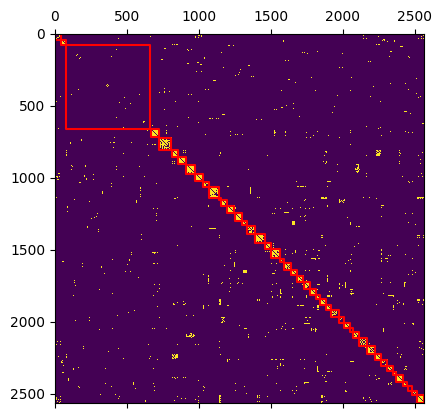

In [ ]:
from utils.visualize import plot_adj_matrix_sorted_by_clustering
from sklearn.metrics import silhouette_score

plot_adj_matrix_sorted_by_clustering(adj_matrix, clustering)

metrics = compute_all_metrics(clustering, uniq_player_ids, c2_df)

from pprint import pprint
pprint(metrics)

silhouette_score_value = silhouette_score(embs, clustering)
print("silhouette_score between embeddings and clustering (more of a metric of the clustering aglorithm on top of embs):", silhouette_score_value)

/tmp/ipykernel_26504/1530776997.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_labels = plt.cm.get_cmap('turbo', len(np.unique(clustering)))(clustering)


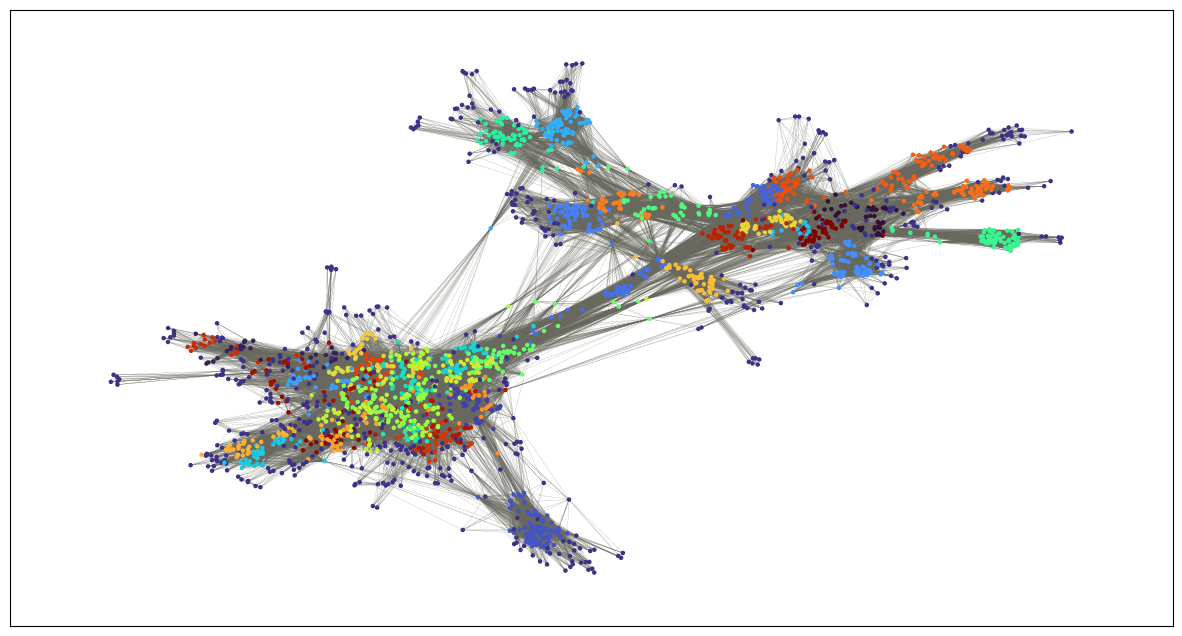

In [ ]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
color_labels = plt.cm.get_cmap('turbo', len(np.unique(clustering)))(clustering)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

In [12]:
#embs = np.load(embeddings_dir / "adjacency_similarity_45.npy")
embs = spectral_embedding(adj_matrix, n_components=n_clusters, random_state=1, drop_first=False)
print("std and mean of spectral_embeddings: ", np.linalg.norm(embs, axis=1).std(), np.linalg.norm(embs, axis=1).mean())
# Max embedding norm
#print(np.mean(embs[0]))
#print(np.linalg.norm(embs[0]))
#print(np.linalg.norm(embs, axis=1).max())
#print(np.linalg.norm(embs, axis=1).min())
embs = np.load(embeddings_dir / "adjacency_similarity_45.npy")
print("std and mean of adjacency_similarity_45: ", np.linalg.norm(embs, axis=1).std(), np.linalg.norm(embs, axis=1).mean())

clustering = KMeans(n_clusters=n_clusters, n_init=10).fit(embs).labels_

unique_labels, counts = np.unique(clustering, return_counts=True)
biggest_cluster = unique_labels[np.argmax(counts)]
biggest_cluster_mean_norm = np.mean(np.linalg.norm(embs[clustering == biggest_cluster], axis=1))
not_in_biggest_cluster_mean_norm = np.mean(np.linalg.norm(embs[clustering != biggest_cluster], axis=1))

print(biggest_cluster_mean_norm, not_in_biggest_cluster_mean_norm)

std and mean of spectral_embeddings:  0.01663529328009647 0.02014781550137026
std and mean of adjacency_similarity_45:  0.35943198 0.7867999
0.2249913 0.95298856


In [13]:
# Indexes in the biggest cluster
biggest_cluster_indexes = np.where(clustering == biggest_cluster)[0]
biggest_cluster_playerids = [adj_index_to_playerid[idx] for idx in biggest_cluster_indexes]

# Number of games for each player
biggest_cluster_num_games = c2_df[c2_df["playerid"].isin(biggest_cluster_playerids)].groupby("playerid").size()
print(biggest_cluster_num_games.describe())

# Number of games for all the other players
not_in_biggest_cluster_num_games = c2_df[~c2_df["playerid"].isin(biggest_cluster_playerids)].groupby("playerid").size()
print(not_in_biggest_cluster_num_games.describe())



count    586.000000
mean       4.977816
std        4.174958
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       29.000000
dtype: float64
count    1981.000000
mean       47.447249
std        37.778620
min         2.000000
25%        17.000000
50%        38.000000
75%        65.000000
max       200.000000
dtype: float64


Player similarities

In [16]:
embs = np.load(embeddings_dir / f"random_walk_embeddings_dim{n_clusters}_window5_jump0.2.npy")
embs /= np.linalg.norm(embs, axis=1, keepdims=True)
faker_embed = embs[247]
embs_sim = embs @ faker_embed
embs_sim_argsort = np.argsort(embs_sim)[::-1]
print(embs_sim_argsort[:10])
second_player_id = adj_index_to_playerid[embs_sim_argsort[1]]
embs_sim_argsort_playerids = [adj_index_to_playerid[idx] for idx in embs_sim_argsort[:10]]
embs_sim_argsort_playernames = [c2_df[c2_df["playerid"] == player_id]["playername"].unique() for player_id in embs_sim_argsort_playerids]
print(embs_sim_argsort_playernames)

[247 246 249 245 286 176 193 170 284 281]
[<StringArray>
['Faker']
Length: 1, dtype: str, <StringArray>
['Oner']
Length: 1, dtype: str, <StringArray>
['Keria']
Length: 1, dtype: str, <StringArray>
['Doran']
Length: 1, dtype: str, <StringArray>
['Viper']
Length: 1, dtype: str, <StringArray>
['Sponge']
Length: 1, dtype: str, <StringArray>
['Lehends']
Length: 1, dtype: str, <StringArray>
['Morgan']
Length: 1, dtype: str, <StringArray>
['Peanut']
Length: 1, dtype: str, <StringArray>
['Ruler']
Length: 1, dtype: str]


Add faker picture